# Refactored piezo patch optimizer runner

This notebook is intentionally thin: define physical parameters/settings, run the standalone optimizer, then plot/post-process results.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Edit this if needed so Python can find Modeling/.
PROJECT_ROOT = Path.cwd().parents[2]
sys.path.append(str(PROJECT_ROOT))

from Modeling.models_fish.FE_helpers_fish import *
from Modeling.models_fish.beam_properties_fish import *
from Modeling.models_fish.piezo_patch_optimizer import *
from Modeling.models_fish.piezo_plotting import *
from Modeling.models_fish.piezo_experiment_runner import *

## Define physical parameters and region types

Replace these values with the exact section-property block from your current notebook if needed.

In [2]:
L = 0.4
b_s = 84e-3       # substrate width [m]
b_p = 62e-3       # active piezo width [m]
h_s = 0.504e-3     # substrate thickness [m]
h_p = 0.3e-3     # one piezo layer thickness [m]
E_s = 3.0e9       # substrate Young's modulus [Pa]
E_p = 31.0e9      # piezo Young's modulus [Pa]
rho_s = 1190.0    # substrate density [kg/m^3]
rho_p = 7800.0    # piezo density [kg/m^3]

# Bare substrate section
EI_substrate = b_s * E_s * h_s**3 / 12.0
rhoA_substrate = b_s * rho_s * h_s

# Active piezo-covered section: substrate + symmetric piezo layers
EI_piezo, rhoA_piezo = compute_EI_and_rhoA(
    E_layers=[E_s, E_p],
    rho_layers=[rho_s, rho_p],
    h_layers=[h_s, h_p],
    b_layers=[b_s, b_p],
)

# build_geometry_from_types accepts optional 'h' for mesh size.
region_types = {
    "piezo":     {"EI": EI_piezo,     "rhoA": rhoA_piezo,     "h": 1.0e-3},
    "substrate": {"EI": EI_substrate, "rhoA": rhoA_substrate, "h": 1.0e-3},
}

print("Region properties:")
for name, props in region_types.items():
    print(f"  {name:10s}: EI = {props['EI']:.4e} N m^2, rhoA = {props['rhoA']:.4e} kg/m")

base_params = PiezoBeamParams(
    b=b_p,              # active piezo width used in theta_mech
    hp=h_p,
    hs=h_s,
    rho_p=rho_p,
    rho_s=rho_s,
    E_s=E_s,
    s11=1.0 / E_p,      # approximate piezo compliance from E_p
    d31=-1.48e-10,
    eps_r=1700.0,
    omega_p=2*np.pi*1.0,
    omega_q=2*np.pi*100.0,
)

# Damping calibration values. Edit these to match COMSOL/experiment.
base_params.zeta_p = 0.05
base_params.zeta_q = 0.20

print("theta_mech =", base_params.theta_mech)
print("Cp_scalar  =", base_params.Cp_scalar)
print("Rayleigh c_alpha, c_beta =", base_params.c_alpha, base_params.c_beta)


Region properties:
  piezo     : EI = 1.9770e-01 N m^2, rhoA = 3.4054e-01 kg/m
  substrate : EI = 2.6885e-03 N m^2, rhoA = 5.0380e-02 kg/m
theta_mech = -0.000228702624
Cp_scalar  = 5.940747413333333e-08
Rayleigh c_alpha, c_beta = 0.19746967160981108 0.000125109962954609


## Configure optimizer

Set `Np=3` and `phase_mode="binary"` to reproduce the previous fixed-3-patch workflow. Change `Np` later when you are ready to test different numbers of patches.

In [3]:
geom_settings = GeometrySettings(
    Np=3,
    patch_length_bounds=(10e-3, 80e-3),
    gap_bounds=(3e-3, 40e-3),
    tip_substrate_bounds=(0.0, L),
)
mode_settings = SingleModeSettings(
    target_mode_number=1,
    voltage_amplitude=1.0,
    phase_mode="binary",
    final_sweep_range_hz=(0.1, 40.0),
    final_sweep_n_freq=1000,
)
circuit_settings = CircuitSettings(R_c=1e3, K_p=0.02, K_i=0.0, K_c=0.0)
opt_settings = OptimizerSettings(
    method="differential_evolution",
    maxiter=10,
    popsize=6,
    seed=2,
    polish=False,
    workers=1,
    n_random_samples=250,
    powell_maxiter=80,
)

optimizer = PiezoPatchOptimizer(
    L=L,
    region_types=region_types,
    base_params=base_params,
    geometry_settings=geom_settings,
    mode_settings=mode_settings,
    circuit_settings=circuit_settings,
    optimizer_settings=opt_settings,
)

print("Design bounds:")
for k, bnd in enumerate(optimizer.make_bounds()):
    print(f"z[{k}]: {1e3*bnd[0]:.3f} to {1e3*bnd[1]:.3f} mm")


Design bounds:
z[0]: 10.000 to 80.000 mm
z[1]: 3.000 to 40.000 mm
z[2]: 10.000 to 80.000 mm
z[3]: 3.000 to 40.000 mm
z[4]: 10.000 to 80.000 mm


## Run optimizer

In [4]:
result = optimizer.run()
best = optimizer.inspect_result(result)

print("Best score [tip displacement/V]:", best["inner"]["score"])
print("Selected natural frequency [Hz]:", best["inner"]["freq_hz"])
print("Natural frequencies [Hz]:", best["fe"].freq[:5])
print("Best design z [mm]:", 1e3 * result.x)
print("Patch xL [mm]:", 1e3 * best["layout"]["xL"])
print("Patch xR [mm]:", 1e3 * best["layout"]["xR"])
print("Phase mode:", best["inner"]["phase_mode"])
print("Phase [deg]:", best["inner"]["phase_deg"])


differential_evolution step 1: f(x)= -0.004229895233238058
differential_evolution step 2: f(x)= -0.00452633716060199
differential_evolution step 3: f(x)= -0.00452633716060199
differential_evolution step 4: f(x)= -0.0045373775005920465
differential_evolution step 5: f(x)= -0.0045373775005920465
differential_evolution step 6: f(x)= -0.0045373775005920465
differential_evolution step 7: f(x)= -0.00454475402601816
differential_evolution step 8: f(x)= -0.004568091141290148
differential_evolution step 9: f(x)= -0.0046016480384326
differential_evolution step 10: f(x)= -0.004638877190643623
Best score [tip displacement/V]: 0.004638877190643623
Selected natural frequency [Hz]: 2.220668972515848
Natural frequencies [Hz]: [ 2.22066897  8.52017454 24.30668547 44.93922611 75.74641599]
Best design z [mm]: [74.76089328  3.08252689 67.18928178  3.62132452 62.38112846]
Patch xL [mm]: [  0.          77.84342017 148.65402647]
Patch xR [mm]: [ 74.76089328 145.03270195 211.03515493]
Phase mode: binary
Phase

In [4]:
def plot_case(record):
    optimizer = record["optimizer"]
    best = record["best"]

    layout = best["layout"]
    inner = best["inner"]
    fe = best["fe"]

    print("Plotting case:", record["summary"])

    plot_layout(layout, L)

    plot_patch_phases(
        layout,
        phase_deg=inner["relative_phase_deg"],
    )

    plot_phase_phasors(
        voltage_vector=inner["voltage_vector"],
    )

    best_frf = optimizer.dense_metric_frf_for_plot(
        fe,
        inner["voltage_vector"],
    )

    plot_metric_frf(
        best_frf,
        natural_freq_hz=inner["freq_hz"],
        label="best phase pattern",
    )

    if inner["phase_mode"] == "binary":
        all_binary = optimizer.dense_all_binary_metric_frf_for_plot(fe)
        plot_all_binary_frf(
            all_binary,
            natural_freq_hz=inner["freq_hz"],
            use_metric=True,
        )
        plot_all_binary_bar(inner["all_phase_results"])

    plt.show()

In [7]:
import json

def _json_safe(obj):
    """Convert numpy/scipy objects to JSON-safe Python objects."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, complex):
        return {"real": obj.real, "imag": obj.imag}
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    return obj


def make_case_name(summary):
    """Create a readable folder name for each run."""
    return (
        f"Np{summary['Np']}_"
        f"mode{summary['mode']}_"
        f"{summary['phase_mode']}_"
        f"{summary['output']}"
    )


def save_case_results(record, root_dir="results_patch_sweep", L=None):
    """
    Save plots and numerical data for one optimizer case.

    Expected record format from run_sweep:
        record["optimizer"]
        record["result"]
        record["best"]
        record["summary"]
    """
    root_dir = Path(root_dir)
    root_dir.mkdir(parents=True, exist_ok=True)

    optimizer = record["optimizer"]
    result = record["result"]
    best = record["best"]
    summary = record["summary"]

    case_name = make_case_name(summary)
    case_dir = root_dir / case_name
    case_dir.mkdir(parents=True, exist_ok=True)

    layout = best["layout"]
    inner = best["inner"]
    fe = best["fe"]

    # -----------------------------
    # Save summary metadata
    # -----------------------------
    summary_to_save = {
        **summary,
        "success": bool(getattr(result, "success", False)),
        "message": str(getattr(result, "message", "")),
        "score": inner["score"],
        "freq_hz": inner["freq_hz"],
        "natural_freqs_hz_first_10": fe.freq[:10],
        "best_design_z_m": result.x,
        "best_design_z_mm": 1e3 * result.x,
        "patch_xL_m": layout["xL"],
        "patch_xR_m": layout["xR"],
        "patch_xL_mm": 1e3 * layout["xL"],
        "patch_xR_mm": 1e3 * layout["xR"],
        "phase_deg": inner.get("phase_deg", None),
        "relative_phase_deg": inner.get("relative_phase_deg", None),
    }

    with open(case_dir / "summary.json", "w") as f:
        json.dump(_json_safe(summary_to_save), f, indent=2)

    # -----------------------------
    # Save compact numerical data
    # -----------------------------
    np.savez(
        case_dir / "design_data.npz",
        z_m=result.x,
        z_mm=1e3 * result.x,
        xL_m=layout["xL"],
        xR_m=layout["xR"],
        xL_mm=1e3 * layout["xL"],
        xR_mm=1e3 * layout["xR"],
        phase_deg=np.asarray(inner.get("phase_deg", []), dtype=float),
        relative_phase_deg=np.asarray(inner.get("relative_phase_deg", []), dtype=float),
        voltage_vector=np.asarray(inner["voltage_vector"]),
        natural_freqs_hz=fe.freq,
        score=inner["score"],
        freq_hz=inner["freq_hz"],
    )

    # -----------------------------
    # Save layout plot
    # -----------------------------
    if L is not None:
        fig, ax = plot_layout(layout, L)
        fig.savefig(case_dir / "layout.png", dpi=300, bbox_inches="tight")
        plt.close(fig)

    # -----------------------------
    # Save phase plots
    # -----------------------------
    fig, ax = plot_patch_phases(
        layout,
        phase_deg=inner["relative_phase_deg"],
    )
    fig.savefig(case_dir / "phase_bar.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plot_phase_phasors(
        voltage_vector=inner["voltage_vector"],
    )
    fig.savefig(case_dir / "phase_phasor.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

    # -----------------------------
    # Save best FRF data + plot
    # -----------------------------
    best_frf = optimizer.dense_metric_frf_for_plot(
        fe,
        inner["voltage_vector"],
    )

    np.savez(
        case_dir / "best_frf.npz",
        freq=best_frf["freq"],
        metric=best_frf["metric"],
        tip_disp=best_frf.get("tip_disp", None),
        mean_abs=best_frf.get("mean_abs", None),
        rms=best_frf.get("rms", None),
    )

    fig, ax = plot_metric_frf(
        best_frf,
        natural_freq_hz=inner["freq_hz"],
        label="best phase pattern",
    )
    fig.savefig(case_dir / "best_frf.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

    # -----------------------------
    # Save binary-only comparison plots/data
    # -----------------------------
    if inner["phase_mode"] == "binary":
        all_binary = optimizer.dense_all_binary_metric_frf_for_plot(fe)

        # Save dense binary FRF data
        np.savez(
            case_dir / "all_binary_frf.npz",
            freq=all_binary[0]["freq"],
            labels=np.array([r["label"] for r in all_binary]),
            metrics=np.array([r["metric"] for r in all_binary]),
        )

        fig, ax = plot_all_binary_frf(
            all_binary,
            natural_freq_hz=inner["freq_hz"],
            use_metric=True,
        )
        fig.savefig(case_dir / "all_binary_frf.png", dpi=300, bbox_inches="tight")
        plt.close(fig)

        fig, ax = plot_all_binary_bar(inner["all_phase_results"])
        fig.savefig(case_dir / "all_binary_bar.png", dpi=300, bbox_inches="tight")
        plt.close(fig)

    print(f"Saved case to: {case_dir}")

In [9]:
config = SweepConfig(
    patch_counts=[2, 3, 4, 5],
    target_modes=[1, 2, 3],
    phase_modes=["binary", "continuous"],
    outputs=["tip", "mean_abs"],

    geometry_kwargs={
        "patch_length_bounds": (5e-3, 89e-3),
        "gap_bounds": (3e-3, 40e-3),
        "tip_substrate_bounds": (0.0, None),
    },

    mode_kwargs={
        "voltage_amplitude": 1.0,
        "final_sweep_range_hz": (0.1, 100.0),
        "final_sweep_n_freq": 1000,
        "continuous_phase_n_starts": 8,
        "continuous_phase_seed": 1,
    },

    optimizer_kwargs={
        "method": "differential_evolution",
        "maxiter": 20,
        "popsize": 8,
        "seed": 2,
        "polish": False,
        "workers": 1,
    },
)

root_dir = "results_patch_sweep"

records = run_sweep(
    L=L,
    region_types=region_types,
    base_params=base_params,
    config=config,
    plot_callback=lambda record: save_case_results(
        record,
        root_dir=root_dir,
        L=L,
    ),
    verbose=True,
)

df = records_to_dataframe(records)
df.to_csv(Path(root_dir) / "sweep_summary.csv", index=False)

df


Case 1/48: Np=2, mode=1, phase=binary, output=tip
Design bounds:
  z[0]: 5.000 to 89.000 mm
  z[1]: 3.000 to 40.000 mm
  z[2]: 5.000 to 89.000 mm
differential_evolution step 1: f(x)= -0.0014075367963457587
differential_evolution step 2: f(x)= -0.0014075367963457587
differential_evolution step 3: f(x)= -0.0014075367963457587


KeyboardInterrupt: 

## Plot layout and final FRF

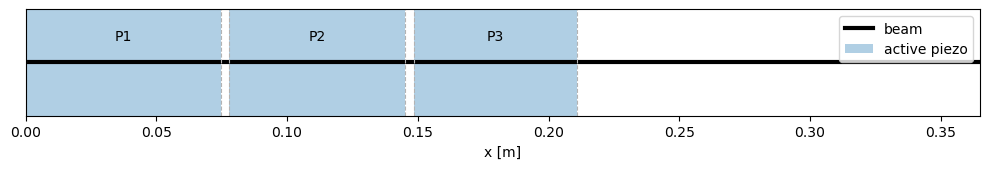

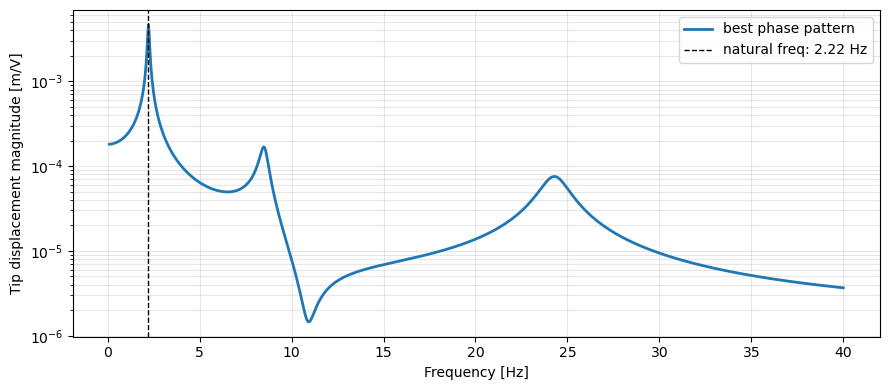

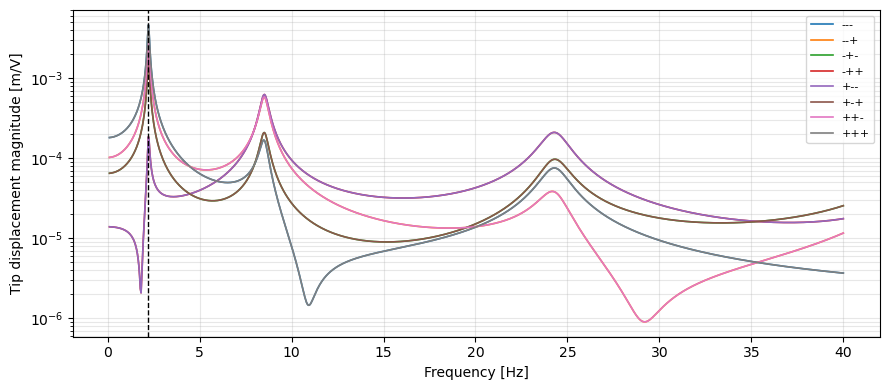

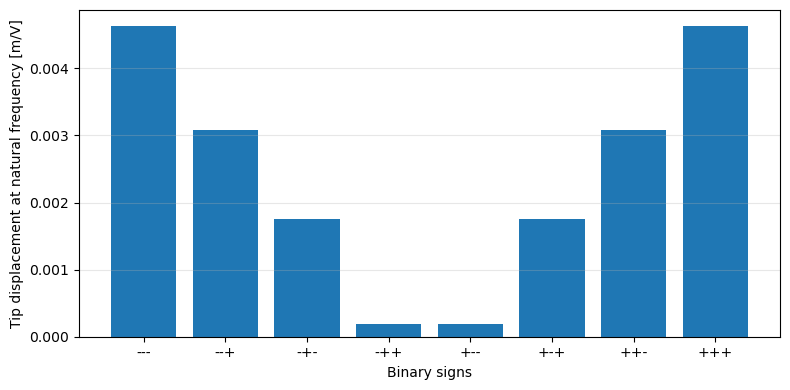

In [5]:
plot_layout(best["layout"], L)

best_frf = optimizer.dense_tip_frf_for_plot(best["fe"], best["inner"]["voltage_vector"])
plot_tip_frf(best_frf, natural_freq_hz=best["inner"]["freq_hz"], label="best phase pattern")

if mode_settings.phase_mode == "binary":
    all_binary = optimizer.dense_all_binary_frf_for_plot(best["fe"])
    plot_all_binary_frf(all_binary, natural_freq_hz=best["inner"]["freq_hz"])
    plot_all_binary_bar(best["inner"]["all_phase_results"])


## Optional: mode shape and curvature / strain proxy

(<Figure size 900x600 with 2 Axes>,
 array([<Axes: ylabel='Mode 1 shape'>,
        <Axes: xlabel='x [m]', ylabel='Curvature $d^2\\phi/dx^2$'>],
       dtype=object))

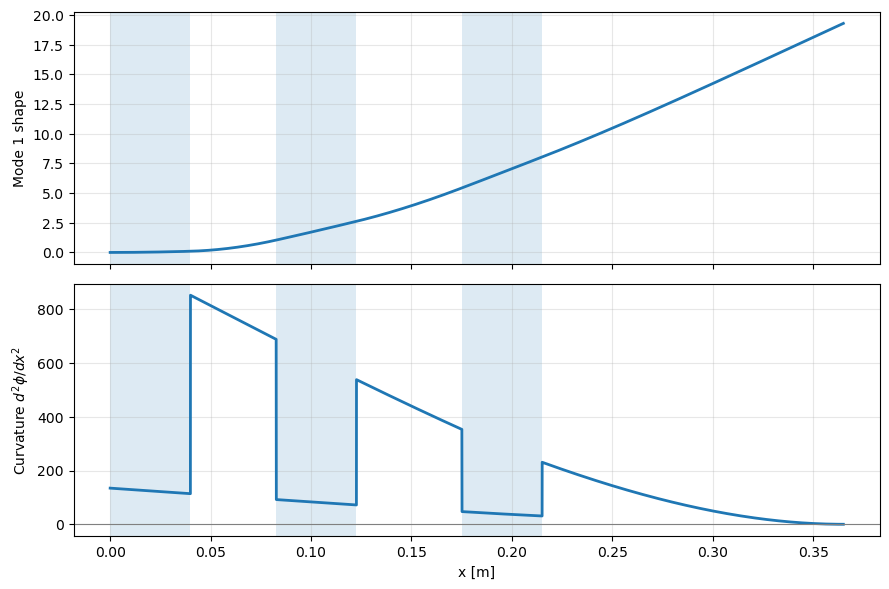

In [ ]:
plot_mode_shape_and_curvature(best["fe"], best["layout"], mode_number=mode_settings.target_mode_number)
